
# 02425 Diffusion and stochastich differential equations


## WEEK 1: Transport

In [161]:
import numpy as np
import random
from matplotlib import pyplot as plt

### Exercise 1

 This exercise will focus on the advection diffusion equation. From here we will investiagiate how a singel particle in the concentration behaves, as funtion of time, instead of measuring the density of the mass over time. Here we will se how the advection coefficient $v$ changes the behavior of the particle in the substance. A particle of the concentration, where the concentration follows the advection diffusion equation, has the following motion:

Note that the solution of the advection diffusion equation on the real line, for a substance, has the following closed form solution.

$$C (x ,t)=\frac{M}{\sqrt{4\pi \mathit{Dt} }} \exp (\frac{-(x-x_0 -\mathit{vt})^{2}}{4\mathit{Dt}})\, , \, x \in \Omega ,t >0$$

Where $C (x ,0)=M \delta (x -x_{0})$, Here $\Omega \subseteq \mathbb{R}$, and $M$ is the mass of the substance, $\delta(x)$ is the dirac delta function at $x_0$ is the start position of the substance. In these exercises we will assume that $M$ = 1.

For a random particle starting at $x_0$ its postion at time $t$ can be expressed as the following:

$$X (t)=x_{0}+\mathit{vt} +\sqrt{2\mathrm{D}}B_{t}$$

Or as

$$dX (t)=d \mathit{vt} +\sqrt{2\mathrm{D}} d B_{t}\, , \, X(0) = x_0$$

Here $B_t$ correpsonds to brownian motion (or wiener process). Note that this equation dosent take it into account that its not a finite domain. Therefore if we work in a bounded domain one can model the system with no flux in the boundaries (as we will do in these exercises). Another approach could be working with absorbing boundaries as in chapter 11.3 in the textbook. Here if the particle hits the boundary it will vanish from the system.

#### a

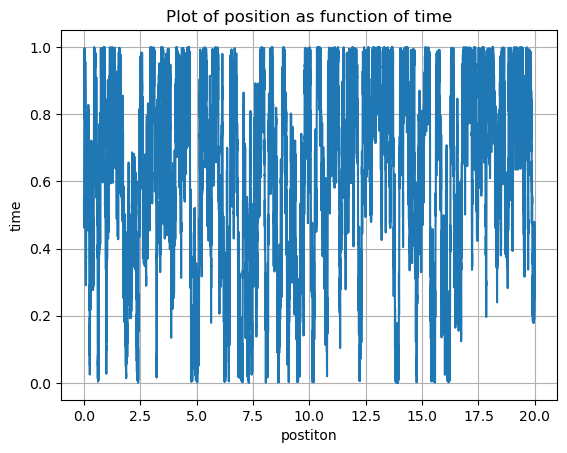

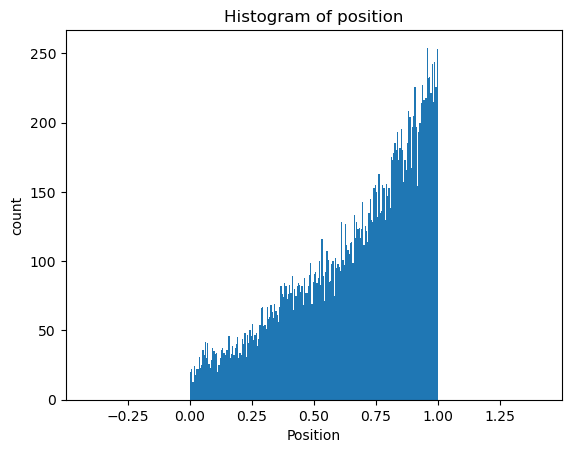

In [162]:
T = 20
delta_t = 10**(-3)
H = 1
D = 1
v = 2



def PositionSimulation(H,D,v,T,delta_t):
    z0 = H/2

    zt = z0

    positions = np.array([])

    for i in range(int(T/delta_t)):
        positions = np.append(positions, zt)
        zt = zt + v * delta_t + np.sqrt(2*D) * np.random.normal(0, np.sqrt(delta_t), 1)

        if zt < 0:
            zt = -1 * zt
        
        if zt > H:
            zt = H - (zt-H)

    return positions





dtaxis = np.linspace(0, T, int(T/delta_t))

plt.plot(dtaxis,  PositionSimulation(H,D,v,T,delta_t))
plt.xlabel("postiton")
plt.ylabel("time")
plt.title("Plot of position as function of time")
plt.grid(True)
plt.show()

bins = np.arange(-100, 100, 0.005) # fixed bin size

plt.xlim([min( PositionSimulation(H,D,v,T,delta_t))-0.5, max( PositionSimulation(H,D,v,T,delta_t))+0.5])

plt.hist(PositionSimulation(H,D,v,T,delta_t), bins=bins, alpha=1)
plt.title('Histogram of position')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()

### b

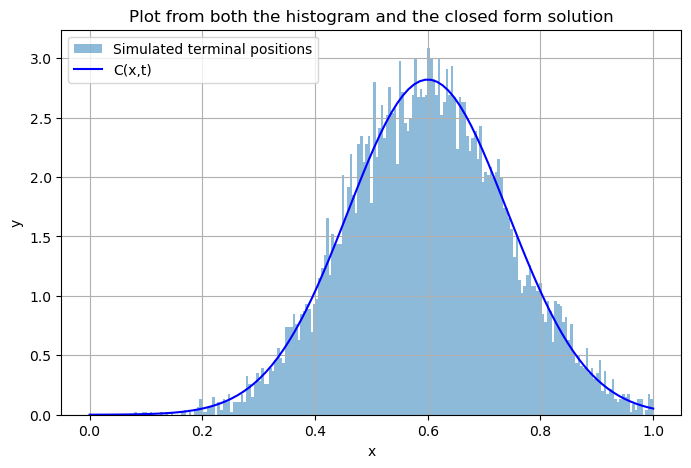

In [ ]:
T = 0.01
delta_t = 10**(-4)
H = 1
D = 1
v = 10

sims = 10000


simulations = np.empty((0, len(PositionSimulation(H,D,v,T,delta_t))))

for i in range(sims):
    simulations = np.vstack([simulations,PositionSimulation(H,D,v,T,delta_t)])


terminalvalues = simulations[:, -1]



def C(x,D,v,t,M):
    x0 = H/2
    return M/np.sqrt(4*np.pi*D*t) *np.exp(-((x-x0-v*t)**2)/(4*D*t))


x_funktion = np.linspace(0, H, int(T/delta_t))
y_funktion = C(x_funktion,D,v,t=T,M=1)


plt.figure(figsize=(8, 5))

plt.hist(
    terminalvalues,
    bins=200,
    density=True,
    alpha=0.5,
    label="Simulated terminal positions"
)


plt.plot(x_funktion, y_funktion, color='blue', label='C(x,t)')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot from both the histogram and the closed form solution')
plt.legend() 
plt.grid(True) 


plt.show()

## Exercise 2

Now we are interested in the problem where $T \rightarrow \infty$. With other words we are interested in the steady state solution of the concentration over the defined domain. Its clear that the problem we are interested to solve is given as the following equation:

$$-v\frac{d}{d\textcolor{white}{x}}C + \mathrm{D}\frac{d^{2}}{d\textcolor{white}{x}^{2}}C = 0$$


This is a second order homogenous linear scalar differential equation and the solution is given as

$$C (x)=c_{0}+c_{1}\exp (\frac{v \cdot x}{\mathrm{D}})$$

From here we have that $c_0$ and $c_1$ be found by the following equation:

$$\int_{\textcolor{white}{0}}^{H}C (x)d x =M =1$$

since we have no flux boundary and the initial mass is chosen to be $M$ = 1, and this should hold through the whole time interval, also in steady state. We know that there are no flux BC in the end point which means that for $x=0$ and $x=H$ the following should hold $\mathit{vC} -\mathit{DC}' =0$
. By plugging in our solution we see that $c_0 = 0$.

We can now find $c_1$

$$\int_{\textcolor{white}{0}}^{H}c_{1}\cdot \exp (\frac{v \cdot x}{\mathrm{D}})d x  = \frac{c_{1} \mathrm{D} \left({\mathrm e}^{\frac{v H}{\mathrm{D}}}-1\right)}{v}$$

$$ \Rightarrow c_{1}=\frac{M v}{\mathrm{D} ({\mathrm e}^{\frac{v H}{\mathrm{D}}}-1)}=\frac{v}{\mathrm{D} ({\mathrm e}^{\frac{v H}{\mathrm{D}}}-1)} $$

We have now found the final solution given by the following:

$$C (x)=\frac{v}{\mathrm{D} ({\mathrm e}^{\frac{v H}{\mathrm{D}}}-1)}\exp (\frac{v \cdot x}{\mathrm{D}})$$

We can now compare the solution of the steady state concentration with the last exercise.

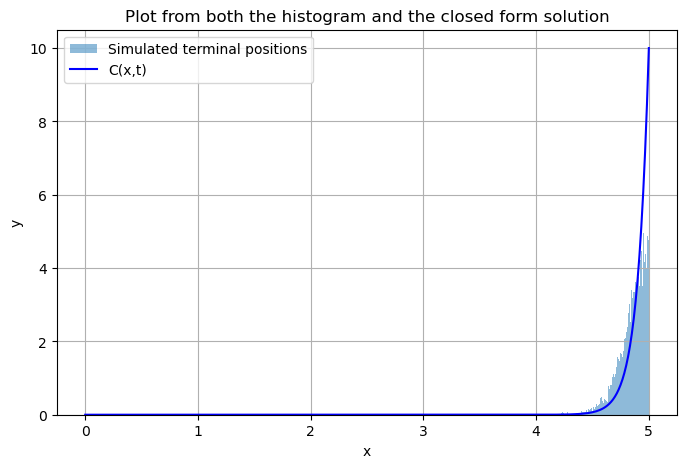

In [164]:
T = 3
delta_t = 10**(-2)
H = 5
D = 1
v = 10

sims = 10000


simulations = np.empty((0, len(PositionSimulation(H,D,v,T,delta_t))))

for i in range(sims):
    simulations = np.vstack([simulations,PositionSimulation(H,D,v,T,delta_t)])


terminalvalues = simulations[:, -1]

def Csteadtstate(x,D,v,M):

    return (np.exp(v*x/D)*v)/(D*(np.exp(v*H/D))-1) 


x_funktion = np.linspace(0, H, int(T/delta_t))
y_funktion = Csteadtstate(x_funktion,D,v,M=1)


plt.figure(figsize=(8, 5))

plt.hist(
    terminalvalues,
    bins=200,
    density=True,
    alpha=0.5,
    label="Simulated terminal positions"
)


plt.plot(x_funktion, y_funktion, color='blue', label='C(x,t)')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot from both the histogram and the closed form solution')
plt.legend() 
plt.grid(True) 


plt.show()

## Exercise 3

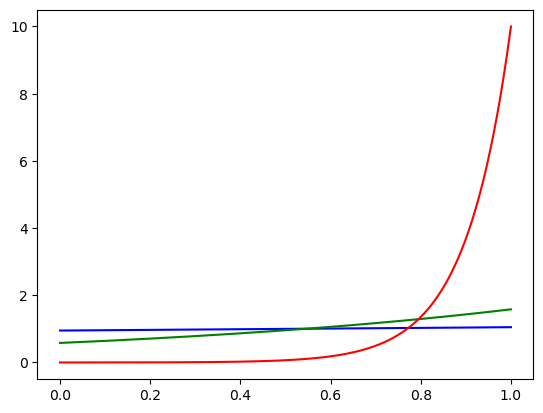

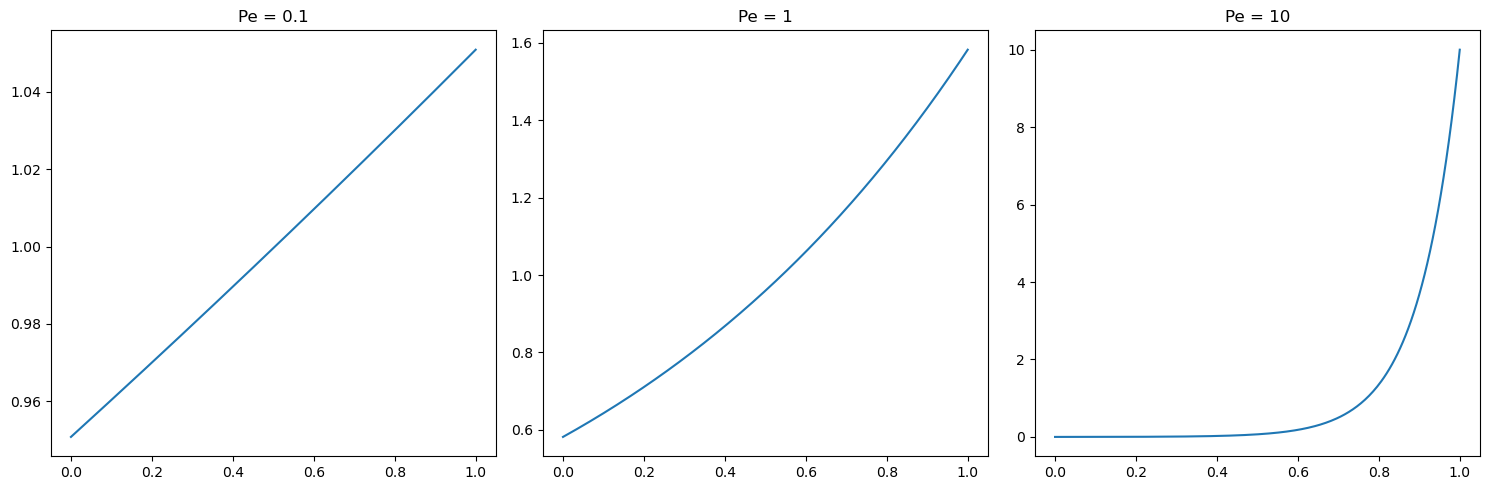

In [165]:
H = 1
D = 1

def Csteadtstate(x,D,v,M):

    return (np.exp(v*x/D)*v)/(D*(np.exp(v*H/D))-1) 


x_funktion = np.linspace(0, H, int(T/delta_t))
y_funktionP01 = Csteadtstate(x_funktion,D,v=0.1,M=1)
y_funktionP1 = Csteadtstate(x_funktion,D,v=1,M=1)
y_funktionP10 = Csteadtstate(x_funktion,D,v=10,M=1)



plt.plot(x_funktion, y_funktionP01, color='blue', label='C(x,t)')
plt.plot(x_funktion, y_funktionP1, color='green', label='C(x,t)')
plt.plot(x_funktion, y_funktionP10, color='red', label='C(x,t)')


fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(x_funktion, y_funktionP01)
ax[1].plot(x_funktion, y_funktionP1)
ax[2].plot(x_funktion, y_funktionP10)

ax[0].set_title("Pe = 0.1")
ax[1].set_title("Pe = 1")
ax[2].set_title("Pe = 10")

plt.tight_layout()
plt.show()

It is clear here that the steadystate function differs from each other, with respect to the Pechlet number. when the Pechlet number is $<<1$, the diffusion is the most domaniating factor in the advection-diffusion process. This is clear by the left side plot, even though it seems it has a positive slope, one can see by the range of y that its nearly constant. This happens because of the diffusion is dominating the process, relatively to the advection which has a minor influence on the process. 

The middle plot showing the steadystate solution for the Pechlet number 1, shows that the advection and diffusion does has the same amount of influece on the process. This can be seen of the wider range on the y-axis, which shows that the function has a influecial slope, still there is some concentration on the x-axis, which shows that the diffusion also is working on the process.

The plot to the right shows the steadystate solution for the process with Pechlet number 10. Here it is clear that the advection has more influence on the process, relatively to the diffusion. This is clear since the concentration of the mass is pushed to the side where the advection is directed to.

## Exersice 4

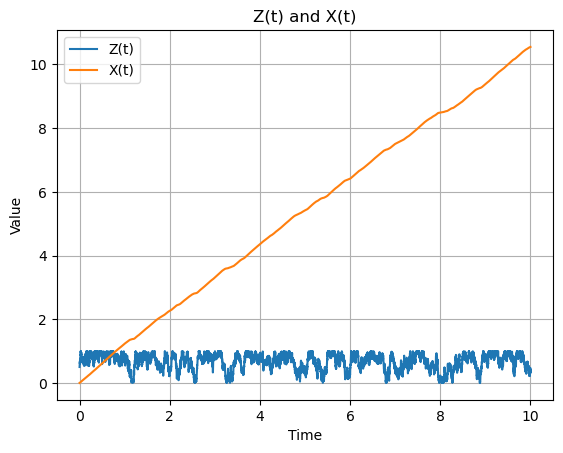

Mean Xt = 10.417270655825355
Var Xt = 0.18186372655203348


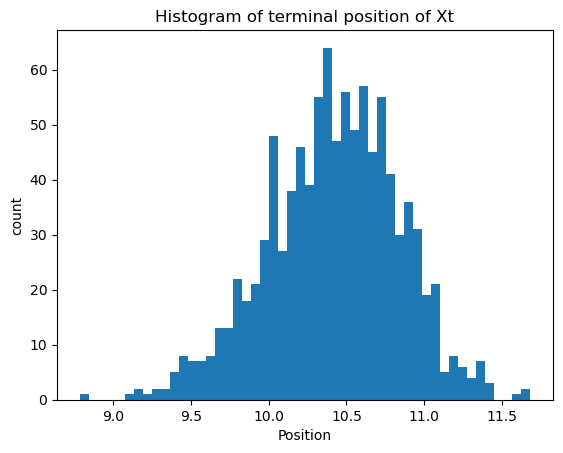

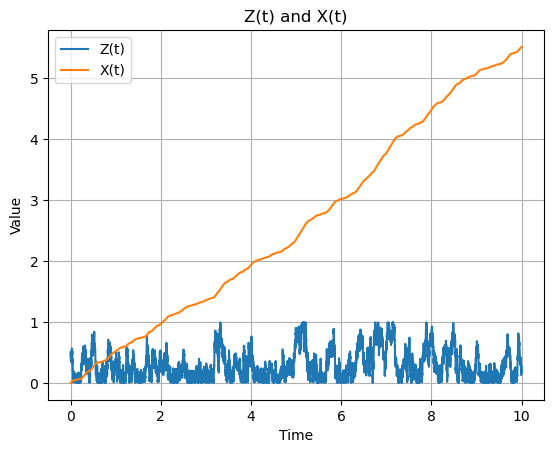

Mean Xt = 6.404187935958551
Var Xt = 0.24863962000870332


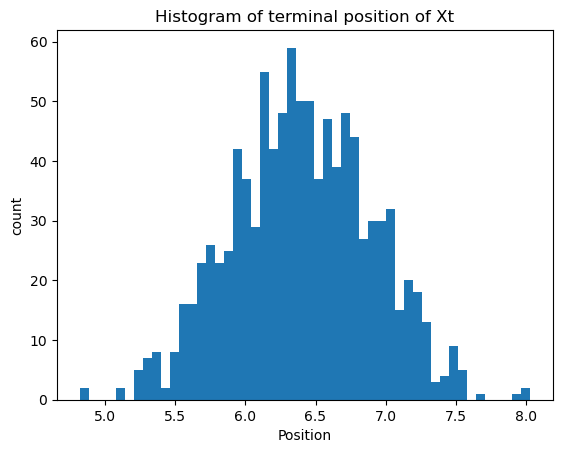

In [ ]:
T = 10
delta_t = 10**(-3)
H = 1
D = 1
v = 2

sims = 1000


positions = PositionSimulation(H, D, v, T, delta_t)

Zt = positions[:, 0]
Xt = positions[:, 1]


dtaxis = np.linspace(0, T, int(T/delta_t))

plt.plot(dtaxis, Zt, label="Z(t)")
plt.plot(dtaxis, Xt, label="X(t)")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Z(t) and X(t)")
plt.legend()
plt.grid(True)
plt.show()


Xt_terminal = np.empty(sims)

for i in range(sims):
    simulation = PositionSimulation(H,D,v,T,delta_t)
    Xt_terminal[i] = simulation[-1,1]


print("Mean Xt =", np.mean(Xt_terminal))
print("Var Xt =", np.var(Xt_terminal))


plt.hist(Xt_terminal, bins=50, alpha=1)

plt.title('Histogram of terminal position of Xt')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()



v = -2


positions = PositionSimulation(H, D, v, T, delta_t)

Zt = positions[:, 0]
Xt = positions[:, 1]


dtaxis = np.linspace(0, T, int(T/delta_t))

plt.plot(dtaxis, Zt, label="Z(t)")
plt.plot(dtaxis, Xt, label="X(t)")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Z(t) and X(t)")
plt.legend()
plt.grid(True)
plt.show()


Xt_terminal = np.empty(sims)

for i in range(sims):
    simulation = PositionSimulation(H,D,v,T,delta_t)
    Xt_terminal[i] = simulation[-1,1]


print("Mean Xt =", np.mean(Xt_terminal))
print("Var Xt =", np.var(Xt_terminal))


plt.hist(Xt_terminal, bins=50, alpha=1)

plt.title('Histogram of terminal position of Xt')
plt.xlabel('Position')
plt.ylabel('count')

plt.show()